In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Neuer Abschnitt

In [ ]:
listings = pd.read_csv("Models/transformer.ipynb")  # venice listings
listings = listings[~listings["price"].isna()]
descriptions_df_0 = listings[['id',
 #'listing_url',
 'scrape_id',
 #'last_scraped',
 #'source',
 #'name', ? maybe include
 'description',
 'price']]
#description.iloc[0]

# Using a small dataset to check the model
descriptions_df = descriptions_df_0.iloc[:descriptions_df_0.shape[0]//5, :]

In [ ]:
# Preprocessing of text for BERT
import re
def convert_currency(text):
    text = re.sub(r'(euro[^s])|(euros)|(€)', ' euros', text) # Convert € sign to text
    text = re.sub(r'(dollar[^s])|(dollars)|($)', ' dollars', text) # Convert $ sign to text
    return text
def convert_m2(text):
    text = re.sub(r'(m2)|(m²)', ' m²', text) # Convert m2 to m²
    return text

def remove_bank_infos(text):
    iban = r'it\{d2}[ ]x\{d3}[ ]\{d4}[ ]\{d4}[ ]\{d4}[ ]\{d4}[ ]\{d3}|it{d25}'
    text = re.sub(iban, '', text) # Should there be a word iban instead. of '' ?
    return text

def remove_emails(text):
    # This part is from https://medium.com/ilb-labs-publications/fine-tuning-bert-for-a-regression-task-is-a-description-enough-to-predict-a-propertys-list-price-cf97cd7cb98a
    email = r'(?:(?!.*?[.]{2})[a-zA-Z0-9](?:[a-zA-Z0-9.+!%-]{1,64}|)|\"[a-zA-Z0-9.+!% -]{1,64}\")@[a-zA-Z0-9][a-zA-Z0-9.-]+(.[a-z]{2,}|.[0-9]{1,})'
    text = re.sub(email, '', text)
    return text

def remove_url(text):
    url = r'(http\:\/\/|https\:\/\/)?([a-z0-9][a-z0-9\-]*\.)+[a-z][a-z\-]*'
    text = re.sub(url, '',  text)
    return text

def remove_phone_numbers(text): # adjust for european phone nums
    number = r'(?:(?:\+|00)39[\s.-]{0,3})?0\d(?:[\s.-]?\d){5,9}' # Filter out itailian phone numbers
    text   = re.sub(number, '', text)
    return text


In [ ]:
# Complete text-cleaning function for BERT
def text_cleaning(text):
    text = text.lower()
    text = text.replace(u'\xa0', u' ') # Replace non-breaking space with normal space
    text = convert_currency(text)
    text = convert_m2(text)
    text = remove_bank_infos(text)
    text = remove_emails(text)
    text = remove_phone_numbers(text)
    text = remove_url(text)
    return text

In [ ]:
# Convert prices to numbers
descriptions_df.loc[:,'price'] = descriptions_df['price'].str.replace('$', '')
descriptions_df.loc[:,'price'] = descriptions_df['price'].str.replace(',', '')
descriptions_df = descriptions_df.astype({'price':'float'})

In [ ]:
# Cleaning of descriptions column
descriptions_df.loc[:,'clean_description'] = descriptions_df.description.fillna('').apply(text_cleaning)

In [ ]:
# Tokenization
from transformers import AutoTokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-uncased")

In [ ]:
encoded_corpus = tokenizer(text=descriptions_df.clean_description.tolist(),
                        add_special_tokens=True,
                        padding='max_length',
                        truncation='longest_first',
                        max_length=300,
                        return_attention_mask=True)

input_ids = encoded_corpus['input_ids']
attention_mask = encoded_corpus['attention_mask']

In [ ]:
import numpy as np
def filter_long_descriptions(tokenizer, descriptions, max_len):
    indices = []
    lengths = tokenizer(descriptions, padding=False,
                     truncation=False, return_length=True)['length']
    for i in range(len(descriptions)):
        if lengths[i] <= max_len-2:
            indices.append(i)
    return indices
short_descriptions = filter_long_descriptions(tokenizer,
                               descriptions_df.clean_description.tolist(), 300)
input_ids = np.array(input_ids)[short_descriptions]
attention_mask = np.array(attention_mask)[short_descriptions]
labels = descriptions_df.price.to_numpy()[short_descriptions]

In [ ]:
from sklearn.model_selection import train_test_split
test_size = 0.2
seed = 42
train_inputs, test_inputs, train_labels, test_labels = \
            train_test_split(input_ids, labels, test_size=test_size,
                             random_state=seed)
train_masks, test_masks, _, _ = train_test_split(attention_mask,
                                        labels, test_size=test_size,
                                        random_state=seed)

In [ ]:
from sklearn.preprocessing import StandardScaler
price_scaler = StandardScaler()
price_scaler.fit(train_labels.reshape(-1, 1))
train_labels = price_scaler.transform(train_labels.reshape(-1, 1))
test_labels = price_scaler.transform(test_labels.reshape(-1, 1))

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
batch_size = 64
def create_dataloaders(inputs, masks, labels, batch_size):
    input_tensor = torch.tensor(inputs)
    mask_tensor = torch.tensor(masks)
    labels_tensor = torch.tensor(labels)
    dataset = TensorDataset(input_tensor, mask_tensor,
                            labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=True)
    return dataloader
train_dataloader = create_dataloaders(train_inputs, train_masks,
                                      train_labels, batch_size)
test_dataloader = create_dataloaders(test_inputs, test_masks,
                                     test_labels, batch_size)

In [ ]:
from transformers import BertModel


class BertRegressor(nn.Module):
    def __init__(self, drop_rate=0.1, freeze_bert=True):
        super(BertRegressor, self).__init__()
        D_in, D_out = 768, 1

        self.bert = BertModel.from_pretrained("bert-base-multilingual-uncased")

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

        self.regressor = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(D_in, D_out),
            nn.ReLU(),
            #nn.Dropout(drop_rate),
            nn.Linear(D_out, D_out)
            # ReLU
            # Linear
        )

    def forward(self, input_ids, attention_mask=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask) # use in the preprocessing
        pooled_output = outputs.pooler_output  # CLS token
        return self.regressor(pooled_output)

model = BertRegressor(drop_rate=0.1)

In [ ]:
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU.")
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")
model.to(device)

Using GPU.


BertRegressor(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [ ]:
#from transformers import Adam
optimizer = torch.optim.AdamW(model.parameters(),
                  lr=1e-4,
                  eps=1e-8)

In [ ]:
from transformers import get_linear_schedule_with_warmup
epochs = 30
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer,
                 num_warmup_steps=0, num_training_steps=total_steps)

In [ ]:
loss_function = nn.MSELoss()


In [ ]:
def evaluate(model, loss_function, test_dataloader, device):
    model.eval()
    #test_loss, test_r2 = [], []
    test_loss, test_r2 = 0, 0
    for batch in test_dataloader:
        batch_inputs, batch_masks, batch_labels = \
                                 tuple(b.to(device) for b in batch)
        with torch.no_grad():
            outputs = model(batch_inputs, batch_masks)
        loss = loss_function(outputs, batch_labels)
        #test_loss.append(loss.item())
        test_loss += loss.item()
        #outputs = outputs.float()
        #batch_labels = batch_labels.float()
        r2 = r2_score(outputs, batch_labels)
        test_r2 += r2.item()
        #test_r2.append(r2.item())
    return test_loss, test_r2
def r2_score(outputs, labels):
    labels_mean = torch.mean(labels)
    ss_tot = torch.sum((labels - labels_mean) ** 2)
    ss_res = torch.sum((labels - outputs) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2


In [ ]:
from torch.nn.utils.clip_grad import clip_grad_norm
def train(model, optimizer, scheduler, loss_function, epochs,
          train_dataloader, device, test_dataloader, clip_value=2):
    model.train()
    #train_loss, train_r2 = [],[]
    train_loss = []
    test_loss, test_r2 = [],[]
    for epoch in range(epochs):
        print(epoch)
        print("-----")
        best_loss = 1e10
        model.train()
        loss_epoch = 0
        r2_epoch = 0
        for step, batch in enumerate(train_dataloader):
            print(step)
            batch_inputs, batch_masks, batch_labels = \
                               tuple(b.to(device) for b in batch)
            model.zero_grad()
            outputs = model(batch_inputs, batch_masks)
            outputs = outputs.to(torch.float32)
            batch_labels = batch_labels.to(torch.float32)
            print("Outputs:", outputs[:5].detach().cpu().numpy())
            print("Labels:", batch_labels[:5].detach().cpu().numpy())

            loss = loss_function(outputs.squeeze(),
                             batch_labels.squeeze())

            loss = loss.float()
            print("Loss:", loss.item())
            #outputs = outputs.float()
            #batch_labels = batch_labels.float()
            #loss = loss_function(outputs.squeeze(), batch_labels.squeeze())
            loss_epoch += loss.item()
            #r2 = r2_score(outputs, batch_labels)
            #r2_epoch += r2.item()

            loss.backward()
            #clip_grad_norm(model.parameters(), clip_value)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()
            scheduler.step()
        train_loss.append(loss_epoch/len(train_dataloader))
        #train_r2.append(r2_epoch/len(train_dataloader))
        test_loss_epoch, test_r2_epoch = evaluate(model, loss_function, test_dataloader, device)
        test_loss.append(test_loss_epoch)
        test_r2.append(test_r2_epoch)
    return model, train_loss, test_loss, test_r2

model, train_loss, test_loss, test_r2 = train(model, optimizer, scheduler, loss_function, epochs,
              train_dataloader, device, test_dataloader, clip_value=2)

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
1
Outputs: [[0.91279954]
 [0.91279954]
 [0.91279954]
 [0.91279954]
 [0.91279954]]
Labels: [[ 0.10587031]
 [-0.15688694]
 [-0.33205843]
 [-0.028877  ]
 [ 1.4802928 ]]
Loss: 1.3572192192077637
2
Outputs: [[0.9127244]
 [0.9127244]
 [0.9127244]
 [0.9127244]
 [0.9127244]]
Labels: [[-0.6150278 ]
 [-0.20404848]
 [-0.19057377]
 [-0.22426058]
 [-0.78346187]]
Loss: 1.4176446199417114
3
Outputs: [[0.91264886]
 [0.91264886]
 [0.91264886]
 [0.91264886]
 [0.91264886]]
Labels: [[-0.6285025 ]
 [-0.40616944]
 [ 0.38883963]
 [-0.3185837 ]
 [-0.7093509 ]]
Loss: 1.3350439071655273
4
Outputs: [[0.9125727]
 [0.9125727]
 [0.9125727]
 [0.9125727]
 [0.9125727]]
Labels: [[-0.33879578]
 [ 0.05870875]
 [ 1.2781719 ]
 [ 0.13281977]
 [-0.13667484]]
Loss: 1.3062552213668823
5
Outputs: [[0.91249657]
 [0.91249657]
 [0.91249657]
 [0.91249657]
 [0.91249657]]
Labels: [[-0.06930119]
 [-0.6082904 ]
 [-0.6082904 ]
 [-0.40616944]
 [-0.04235173]]
Loss: 1.56617

In [ ]:
#test_loss, test_r2 = evaluate(model, loss_function, test_dataloader, device)


In [ ]:
# TODO write a plot function
def plot_losses_epochs(n_epoch,train_losses, val_losses):
    # n_epoch of type int
    # train_losses of type list
    # val_losses of type list
    epochs = [e+1 for e in range(n_epoch)]

    # Create DataFrame for Seaborn
    loss_df = pd.DataFrame({
        'Epoch': epochs * 2,
        'Loss': train_losses + val_losses,
        'Set': ['Training results'] * len(epochs) + ['Validation results'] * len(epochs)
    })

    # Plot
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=loss_df,
        x='Epoch',
        y='Loss',
        hue='Set',
        style='Set',
        markers=True,
        dashes=True
    )
    plt.title("Epoch vs. Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xlim(1, len(epochs))
    plt.show()


In [ ]:
test_r2

[-0.061932537712114044,
 -0.02073899395524159,
 -0.07342530842621864,
 -0.042529730804949484,
 -0.1458275396643447,
 -0.029074933275426984,
 -0.04179465367182478,
 -0.13932106033997194,
 -0.1578095468585049,
 -0.06019134811092153,
 -0.14480911037634336,
 -0.07297390049604258,
 -0.4212112305507394,
 -0.1775815184325884,
 -0.07004584237173028,
 -0.2209779741161717,
 -0.0284631918072058,
 -0.06057838724187481,
 -0.08694632326811624,
 -0.04971552067934448,
 -0.025831845186920388,
 -0.06614228182132997,
 -0.03581712550539806,
 -0.1981211692584961,
 -0.21307162191412377,
 -0.10492360523764699,
 -0.005477499042900735,
 -0.40570605876127375,
 -0.10826548255058643,
 -0.12901661836545264]

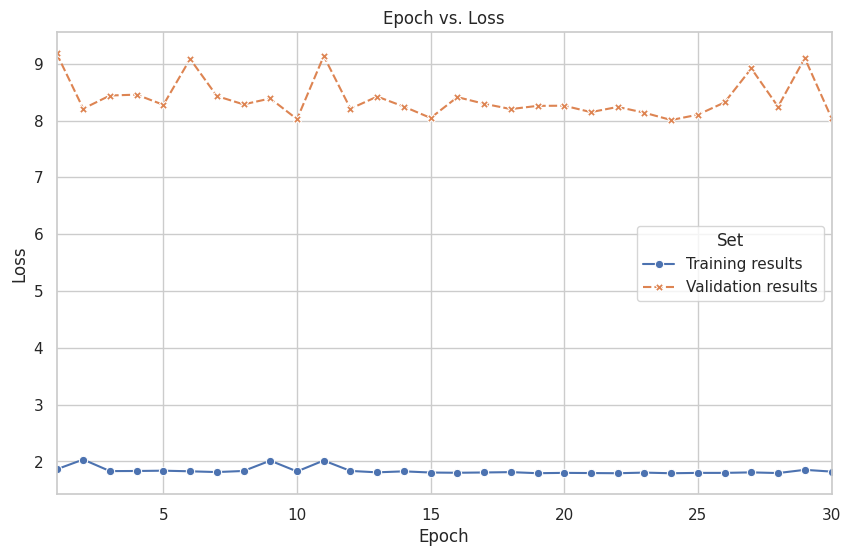

In [ ]:
plot_losses_epochs(epochs,train_loss, test_loss)
# the plot looks weird --> change the hyperparams
#train_loss